# modelagem de classificação multiclasse

## human activity recognition com dados de smartphone

neste notebook, o objetivo é treinar e comparar modelos de machine learning capazes de prever a atividade humana realizada por uma pessoa com base em dados de sensores do smartphone

a variável alvo é `Activity`, que reúne seis classes distintas: `WALKING`, `WALKING_UPSTAIRS`, `WALKING_DOWNSTAIRS`, `SITTING`, `STANDING` e `LAYING`. portanto, este é um problema de classificação multiclasse

além de comparar algoritmos diferentes, também serão avaliados três cenários de features:

- **experimento 1:** manter a coluna `subject`;
- **experimento 2:** remover a coluna `subject`;
- **experimento 3:** remover `subject` e utilizar apenas as features selecionadas com base na análise exploratória.

a coluna `subject` identifica o participante. ela pode capturar padrões individuais de execução do movimento e, por isso, introduzir um atalho que melhora a métrica sem necessariamente representar melhor a atividade em si. por esse motivo, a abordagem sem `subject` será tratada como a versão principal do projeto

já o terceiro experimento foi incluído para testar se uma base menor e menos redundante, construída a partir da seleção de variáveis feita na EDA, consegue manter desempenho competitivo em relação à base completa

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display, Markdown
except ImportError:
    def display(obj):
        print(obj)
    def Markdown(text):
        return text
from matplotlib.colors import LinearSegmentedColormap

from sklearn.base import clone
from sklearn.model_selection import (
    StratifiedKFold,
    GroupKFold,
    cross_val_score,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

dark_palette = [
    "#4B000F",
    "#7A001F",
    "#A83246",
    "#C45A6A",
    "#2B2D42",
    "#1F1F2E",
    "#8D99AE",
    "#D8DEE9"
]

sns.set_theme(
    style="whitegrid",
    palette=dark_palette,
    font_scale=1.05
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

cmap = LinearSegmentedColormap.from_list("sensor_dark", dark_palette)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

## carregamento dos dados

o dataset já está dividido em treino e teste. isso permite comparar os modelos de forma direta em um conjunto final que também contém a variável alvo real.


In [2]:
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")

display(train_df.head())
print(f"Treino: {train_df.shape[0]} linhas e {train_df.shape[1]} colunas")
print(f"Teste: {test_df.shape[0]} linhas e {test_df.shape[1]} colunas")

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,tBodyAcc-max()-Y,tBodyAcc-max()-Z,tBodyAcc-min()-X,tBodyAcc-min()-Y,tBodyAcc-min()-Z,tBodyAcc-sma(),tBodyAcc-energy()-X,tBodyAcc-energy()-Y,tBodyAcc-energy()-Z,tBodyAcc-iqr()-X,tBodyAcc-iqr()-Y,tBodyAcc-iqr()-Z,tBodyAcc-entropy()-X,tBodyAcc-entropy()-Y,tBodyAcc-entropy()-Z,"tBodyAcc-arCoeff()-X,1","tBodyAcc-arCoeff()-X,2","tBodyAcc-arCoeff()-X,3","tBodyAcc-arCoeff()-X,4","tBodyAcc-arCoeff()-Y,1","tBodyAcc-arCoeff()-Y,2","tBodyAcc-arCoeff()-Y,3","tBodyAcc-arCoeff()-Y,4","tBodyAcc-arCoeff()-Z,1","tBodyAcc-arCoeff()-Z,2","tBodyAcc-arCoeff()-Z,3","tBodyAcc-arCoeff()-Z,4","tBodyAcc-correlation()-X,Y","tBodyAcc-correlation()-X,Z","tBodyAcc-correlation()-Y,Z",tGravityAcc-mean()-X,tGravityAcc-mean()-Y,tGravityAcc-mean()-Z,tGravityAcc-std()-X,tGravityAcc-std()-Y,tGravityAcc-std()-Z,tGravityAcc-mad()-X,tGravityAcc-mad()-Y,tGravityAcc-mad()-Z,tGravityAcc-max()-X,tGravityAcc-max()-Y,tGravityAcc-max()-Z,tGravityAcc-min()-X,tGravityAcc-min()-Y,tGravityAcc-min()-Z,tGravityAcc-sma(),tGravityAcc-energy()-X,tGravityAcc-energy()-Y,tGravityAcc-energy()-Z,tGravityAcc-iqr()-X,...,fBodyAccMag-std(),fBodyAccMag-mad(),fBodyAccMag-max(),fBodyAccMag-min(),fBodyAccMag-sma(),fBodyAccMag-energy(),fBodyAccMag-iqr(),fBodyAccMag-entropy(),fBodyAccMag-maxInds,fBodyAccMag-meanFreq(),fBodyAccMag-skewness(),fBodyAccMag-kurtosis(),fBodyBodyAccJerkMag-mean(),fBodyBodyAccJerkMag-std(),fBodyBodyAccJerkMag-mad(),fBodyBodyAccJerkMag-max(),fBodyBodyAccJerkMag-min(),fBodyBodyAccJerkMag-sma(),fBodyBodyAccJerkMag-energy(),fBodyBodyAccJerkMag-iqr(),fBodyBodyAccJerkMag-entropy(),fBodyBodyAccJerkMag-maxInds,fBodyBodyAccJerkMag-meanFreq(),fBodyBodyAccJerkMag-skewness(),fBodyBodyAccJerkMag-kurtosis(),fBodyBodyGyroMag-mean(),fBodyBodyGyroMag-std(),fBodyBodyGyroMag-mad(),fBodyBodyGyroMag-max(),fBodyBodyGyroMag-min(),fBodyBodyGyroMag-sma(),fBodyBodyGyroMag-energy(),fBodyBodyGyroMag-iqr(),fBodyBodyGyroMag-entropy(),fBodyBodyGyroMag-maxInds,fBodyBodyGyroMag-meanFreq(),fBodyBodyGyroMag-skewness(),fBodyBodyGyroMag-kurtosis(),fBodyBodyGyroJerkMag-mean(),fBodyBodyGyroJerkMag-std(),fBodyBodyGyroJerkMag-mad(),fBodyBodyGyroJerkMag-max(),fBodyBodyGyroJerkMag-min(),fBodyBodyGyroJerkMag-sma(),fBodyBodyGyroJerkMag-energy(),fBodyBodyGyroJerkMag-iqr(),fBodyBodyGyroJerkMag-entropy(),fBodyBodyGyroJerkMag-maxInds,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,-0.567378,-0.744413,0.852947,0.685845,0.814263,-0.965523,-0.999945,-0.999863,-0.994612,-0.994231,-0.987614,-0.943220,-0.407747,-0.679338,-0.602122,0.929294,-0.853011,0.359910,-0.058526,0.256892,-0.224848,0.264106,-0.095246,0.278851,-0.465085,0.491936,-0.190884,0.376314,0.435129,0.660790,0.963396,-0.140840,0.115375,-0.985250,-0.981708,-0.877625,-0.985001,-0.984416,-0.894677,0.892055,-0.161265,0.124660,0.977436,-0.123213,0.056483,-0.375426,0.899469,-0.970905,-0.975510,-0.984325,...,-0.956134,-0.948870,-0.974321,-0.925722,-0.952155,-0.998285,-0.973273,-0.646376,-0.793103,-0.088436,-0.436471,-0.796840,-0.993726,-0.993755,-0.991976,-0.993365,-0.988175,-0.993726,-0.999918,-0.991364,-1.0,-0.936508,0.346989,-0.516080,-0.802760,-0.980135,-0.961309,-0.973653,-0.952264,-0.989498,-0.980135,-0.999240,-0.992656,-0.701291,-1.000000,-0.128989,0.586156,0.374605,-0.991990,-0.990697,-0.989941,-0.992448,-0.991048,-0.991990,-0.999937,-0.990458,-0.871306,-1.000000,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-

Treino: 7352 linhas e 563 colunas
Teste: 2947 linhas e 563 colunas


## preparação dos dados

primeiro, vamos separar as features da variável alvo e construir os dois experimentos comparativos

- no cenário **com `subject`**, o modelo recebe o identificador do participante;
- no cenário **sem `subject`**, o modelo aprende apenas a partir dos sinais e atributos derivados dos sensores.

aqui podemos considerar o segundo cenário mais conservador, pois ele reduz o risco de o modelo aprender traços do indivíduo em vez do padrão da atividade humana

In [3]:
target = "Activity"

X_train_full = train_df.drop(target, axis=1)
y_train_full = train_df[target]

X_test_full = test_df.drop(target, axis=1)
y_test_full = test_df[target]

subject_groups = train_df["subject"] if "subject" in train_df.columns else pd.Series(np.arange(len(train_df)))
recommended_experiment = "sem_subject" if "subject" in train_df.columns else "com_subject"

experiments = {
    "com_subject": {
        "X_train": X_train_full.copy(),
        "X_test": X_test_full.copy(),
        "description": "Mantém a coluna subject no conjunto de features."
    }
}

if "subject" in X_train_full.columns:
    experiments["sem_subject"] = {
        "X_train": X_train_full.drop(columns=["subject"]).copy(),
        "X_test": X_test_full.drop(columns=["subject"]).copy(),
        "description": "Remove a coluna subject para reduzir o efeito de identificação do participante."
    }
else:
    experiments["sem_subject"] = {
        "X_train": X_train_full.copy(),
        "X_test": X_test_full.copy(),
        "description": "O dataset não possui a coluna subject, então os dois cenários coincidem."
    }

experiment_shapes = pd.DataFrame({
    experiment_name: {
        "linhas_treino": config["X_train"].shape[0],
        "colunas_treino": config["X_train"].shape[1],
        "linhas_teste": config["X_test"].shape[0],
        "colunas_teste": config["X_test"].shape[1]
    }
    for experiment_name, config in experiments.items()
}).T

display(experiment_shapes)

,linhas_treino,colunas_treino,linhas_teste,colunas_teste
com_subject,7352,562,2947,562
sem_subject,7352,561,2947,561


a análise principal do notebook seguirá com o experimento sem_subject, por ser a opção metodologicamente mais segura para generalização

## codificação da variável alvo

como `Activity` é uma variável textual, vamos usar `LabelEncoder` para transformá-la em códigos numéricos. essa etapa é necessária porque os modelos do scikit-learn trabalham melhor com rótulos numéricos

In [4]:
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train_full)
y_test_encoded = label_encoder.transform(y_test_full)
class_names = label_encoder.classes_

pd.DataFrame({
    "classe_original": class_names,
    "classe_codificada": range(len(class_names))
})

,classe_original,classe_codificada
0,LAYING,0
1,SITTING,1
2,STANDING,2
3,WALKING,3
4,WALKING_DOWNSTAIRS,4
5,WALKING_UPSTAIRS,5


## experimento 3: sem subject + features selecionadas

na EDA, vimos que a base possui muitas variáveis altamente correlacionadas entre si. isso levanta uma hipótese importante para a modelagem de que talvez seja possível trabalhar com uma base menor e menos redundante sem perder muito desempenho

este terceiro experimento parte exatamente dessa ideia. a proposta é:

- remover a coluna `subject`, mantendo a mesma lógica do experimento principal;
- selecionar apenas features com maior correlação com a target codificada;
- evitar manter variáveis muito parecidas entre si, usando um limite de correlação absoluta acima de `0.70`.

esse teste não substitui automaticamente a base completa. ele serve para comparar se um conjunto reduzido consegue preservar desempenho competitivo, com potencial ganho de simplicidade, interpretação e custo computacional

In [5]:
def select_relevant_features(
    features_df,
    target_encoded,
    inter_feature_corr_threshold=0.70,
    top_n=None,
    method="pearson",
):
    target_series = pd.Series(target_encoded, index=features_df.index, name="target_encoded")

    target_corr = (
        features_df.apply(lambda col: col.corr(target_series, method=method))
        .abs()
        .fillna(0.0)
    )

    ranking_df = (
        target_corr.sort_values(ascending=False)
        .rename("target_corr_abs")
        .rename_axis("feature")
        .reset_index()
    )

    feature_corr_matrix = features_df.corr(method=method).abs()
    target_corr_map = dict(zip(ranking_df["feature"], ranking_df["target_corr_abs"]))

    selected_features = []
    removed_records = []

    for feature in ranking_df["feature"]:
        redundant_with = None
        inter_feature_corr = None

        for selected_feature in selected_features:
            corr_value = feature_corr_matrix.loc[feature, selected_feature]

            if pd.notna(corr_value) and corr_value > inter_feature_corr_threshold:
                redundant_with = selected_feature
                inter_feature_corr = corr_value
                break

        if redundant_with is None:
            selected_features.append(feature)
        else:
            removed_records.append(
                {
                    "feature_removida": feature,
                    "target_corr_abs": target_corr_map[feature],
                    "feature_mantida": redundant_with,
                    "target_corr_abs_mantida": target_corr_map[redundant_with],
                    "correlacao_entre_features": inter_feature_corr,
                }
            )

    if top_n is not None:
        selected_features = selected_features[:top_n]

    removed_df = pd.DataFrame(removed_records)
    if not removed_df.empty:
        removed_df = removed_df.sort_values(
            ["correlacao_entre_features", "target_corr_abs"],
            ascending=[False, False]
        ).reset_index(drop=True)
    else:
        removed_df = pd.DataFrame(
            columns=[
                "feature_removida",
                "target_corr_abs",
                "feature_mantida",
                "target_corr_abs_mantida",
                "correlacao_entre_features",
            ]
        )

    return selected_features, ranking_df, removed_df

In [6]:
base_experiment_key = "sem_subject"
selected_experiment_key = "sem_subject_features_selecionadas"

base_train_no_subject = experiments[base_experiment_key]["X_train"].copy()
base_test_no_subject = experiments[base_experiment_key]["X_test"].copy()

selected_feature_list, selected_feature_ranking_df, removed_selected_features_df = select_relevant_features(
    base_train_no_subject,
    y_train_encoded,
    inter_feature_corr_threshold=0.70,
    top_n=None,
    method="pearson",
)

X_train_selected = base_train_no_subject[selected_feature_list].copy()
X_test_selected = base_test_no_subject[selected_feature_list].copy()

experiments[selected_experiment_key] = {
    "X_train": X_train_selected,
    "X_test": X_test_selected,
    "description": "Remove subject e mantém apenas features selecionadas por correlação com a target e baixa redundância.",
}

experiment_shapes = pd.DataFrame({
    experiment_name: {
        "linhas_treino": config["X_train"].shape[0],
        "colunas_treino": config["X_train"].shape[1],
        "linhas_teste": config["X_test"].shape[0],
        "colunas_teste": config["X_test"].shape[1]
    }
    for experiment_name, config in experiments.items()
}).T

selection_summary_modeling_df = pd.DataFrame({
    "métrica": [
        "Features no experimento sem subject",
        "Features selecionadas para o experimento 3",
        "Features removidas por redundância",
    ],
    "valor": [
        base_train_no_subject.shape[1],
        len(selected_feature_list),
        len(removed_selected_features_df),
    ]
})

feature_preview_df = selected_feature_ranking_df[
    selected_feature_ranking_df["feature"].isin(selected_feature_list)
].head(15)

display(experiment_shapes)
display(selection_summary_modeling_df)
display(feature_preview_df)
display(removed_selected_features_df.head(10))

,linhas_treino,colunas_treino,linhas_teste,colunas_teste
com_subject,7352,562,2947,562
sem_subject,7352,561,2947,561
sem_subject_features_selecionadas,7352,140,2947,140


,métrica,valor
0,Features no experimento sem subject,561
1,Features selecionadas para o experimento 3,140
2,Features removidas por redundância,421


,feature,target_corr_abs
0,fBodyAccJerk-entropy()-X,0.845190
135,tGravityAcc-min()-Y,0.749414
206,"fBodyAcc-bandsEnergy()-1,8.2",0.660492
225,"tBodyGyro-arCoeff()-Z,1",0.642150
236,tGravityAcc-min()-Z,0.631560
243,fBodyAccJerk-meanFreq()-Z,0.618574
252,"tBodyAccJerk-arCoeff()-Y,1",0.605988
270,"fBodyGyro-bandsEnergy()-1,8",0.577606
272,tBodyAccJerkMag-arCoeff()1,0.575811
285,"tBodyGyro-arCoeff()-X,1",0.553514


,feature_removida,target_corr_abs,feature_mantida,target_corr_abs_mantida,correlacao_entre_features
0,tBodyAccMag-arCoeff()1,0.525731,tGravityAccMag-arCoeff()1,0.525731,1.000000
1,tBodyAccMag-arCoeff()3,0.357193,tGravityAccMag-arCoeff()3,0.357193,1.000000
2,tGravityAcc-mad()-Z,0.138240,tGravityAcc-std()-Z,0.140106,0.998622
3,tGravityAcc-mean()-Z,0.625985,tGravityAcc-min()-Z,0.631560,0.996446
4,tGravityAcc-mean()-Y,0.748398,tGravityAcc-min()-Y,0.749414,0.996399
5,"fBodyAccJerk-bandsEnergy()-49,64.1",0.503807,"fBodyAccJerk-bandsEnergy()-49,56.1",0.503917,0.996364
6,"tGravityAcc-arCoeff()-Z,3",0.194024,"tGravityAcc-arCoeff()-Z,4",0.236423,0.994256
7,fBodyBodyAccJerkMag-entropy(),0.829260,fBodyAccJerk-entropy()-X,0.845190,0.992583
8,"angle(Z,gravityMean)",0.611528,tGravityAcc-min()-Z,0.631560,0.990991
9,"angle(Y,gravityMean)",0.725408,tGravityAcc-min()-Y,0.749414,0.990047


lógica do experimento 3: reaproveitar apenas as features escolhidas no treino e aplicar exatamente esse mesmo conjunto ao teste. isso evita vazamento de informação e mantém a comparação metodologicamente consistente com os outros cenários.

## modelos testados

serão comparados modelos lineares, baseados em árvore, baseados em vizinhança e uma versão com SVM. para algoritmos sensíveis à escala, usamos `Pipeline` com `StandardScaler`

In [7]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42, n_estimators=200, n_jobs=-1),
    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier())
    ]),
    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(random_state=42))
    ])
}

list(models.keys())

['Logistic Regression', 'Decision Tree', 'Random Forest', 'KNN', 'SVM']

## função de avaliação

a função abaixo treina cada modelo, gera previsões no conjunto de teste e armazena métricas, relatórios e matrizes de confusão

métricas para validação:

- **accuracy:** proporção total de acertos;
- **macro F1:** média do F1 tratando todas as classes com o mesmo peso;
- **weighted F1:** média ponderada pelo tamanho de cada classe.

a métrica principal será weighted F1. ela é útil aqui porque combina precisão e recall por classe, mas ainda respeita o suporte de cada atividade. como o dataset é relativamente balanceado, mas não perfeitamente uniforme, essa métrica oferece uma leitura mais robusta do desempenho global do que olhar apenas para accuracy

In [8]:
def evaluate_model(model_name, model, X_train, y_train, X_test, y_test, class_names, experiment_name):
    estimator = clone(model)
    estimator.fit(X_train, y_train)
    y_pred = estimator.predict(X_test)

    result = {
        "experimento": experiment_name,
        "modelo": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "macro_f1": f1_score(y_test, y_pred, average="macro"),
        "weighted_f1": f1_score(y_test, y_pred, average="weighted")
    }

    artifacts = {
        "model": estimator,
        "predictions": y_pred,
        "classification_report": classification_report(
            y_test,
            y_pred,
            target_names=class_names,
            output_dict=True,
            zero_division=0
        ),
        "confusion_matrix": confusion_matrix(y_test, y_pred),
        "X_train": X_train,
        "X_test": X_test
    }

    return result, artifacts

## comparação dos modelos

agora vamos rodar todos os modelos nos dois experimentos e organizar os resultados em uma tabela ordenada pela melhor pontuação de `weighted_f1`

In [9]:
results = []
artifacts = {}

for experiment_name, config in experiments.items():
    for model_name, model in models.items():
        result, model_artifacts = evaluate_model(
            model_name=model_name,
            model=model,
            X_train=config["X_train"],
            y_train=y_train_encoded,
            X_test=config["X_test"],
            y_test=y_test_encoded,
            class_names=class_names,
            experiment_name=experiment_name
        )
        results.append(result)
        artifacts[(experiment_name, model_name)] = model_artifacts

results_df = pd.DataFrame(results).sort_values(
    by=["weighted_f1", "macro_f1", "accuracy"],
    ascending=False
).reset_index(drop=True)

results_df["ranking"] = np.arange(1, len(results_df) + 1)
results_df["abordagem_principal"] = np.where(
    results_df["experimento"] == recommended_experiment,
    "sim",
    "não"
)

comparison_table = results_df[
    ["ranking", "experimento", "abordagem_principal", "modelo", "accuracy", "macro_f1", "weighted_f1"]
].copy()

display(comparison_table.round({
    "accuracy": 4,
    "macro_f1": 4,
    "weighted_f1": 4
}))

recommended_results = (
    results_df[results_df["experimento"] == recommended_experiment]
    .sort_values(by=["weighted_f1", "macro_f1", "accuracy"], ascending=False)
    .reset_index(drop=True)
)
recommended_best_row = recommended_results.iloc[0]

,ranking,experimento,abordagem_principal,modelo,accuracy,macro_f1,weighted_f1
0,1,sem_subject,sim,Logistic Regression,0.9535,0.9532,0.9534
1,2,com_subject,não,Logistic Regression,0.9525,0.9527,0.9525
2,3,com_subject,não,SVM,0.9525,0.9519,0.9524
3,4,sem_subject,sim,SVM,0.9518,0.9511,0.9517
4,5,sem_subject_features_selecionadas,não,SVM,0.9437,0.9440,0.9438
5,6,sem_subject_features_selecionadas,não,Random Forest,0.9369,0.9365,0.9369
6,7,sem_subject_features_selecionadas,não,Logistic Regression,0.9315,0.9321,0.9318
7,8,com_subject,não,Random Forest,0.9291,0.9271,0.9290
8,9,sem_subject,sim,Random Forest,0.9291,0.9275,0.9289
9,10,com_subject,não,KNN,0.8843,0.8811,0.8834


## leitura da comparação

a tabela acima organiza os experimentos por `weighted_f1`, que será a referência principal da escolha. além do ranking geral, a coluna `abordagem_principal` ajuda a destacar quais resultados pertencem ao cenário recomendado, isto é, sem `subject`

In [25]:
best_per_experiment = (
    results_df
    .sort_values(by="weighted_f1", ascending=False)
    .groupby("experimento", as_index=False)
    .first()
)

display(best_per_experiment.round(4))

,experimento,modelo,accuracy,macro_f1,weighted_f1,ranking,abordagem_principal
0,com_subject,Logistic Regression,0.9525,0.9527,0.9525,2,não
1,sem_subject,Logistic Regression,0.9535,0.9532,0.9534,1,sim
2,sem_subject_features_selecionadas,SVM,0.9437,0.9440,0.9438,5,não


- a melhor configuração foi a **Logistic Regression** no experimento **sem_subject**, com o maior `weighted_f1` da comparação

- o fato de a versão sem `subject` superar ligeiramente a versão com `subject` reforça que remover essa coluna não prejudicou o desempenho e ainda torna a abordagem mais segura do ponto de vista metodológico

- no experimento com **features selecionadas**, o melhor resultado veio com **SVM**. houve perda de desempenho em relação à base completa, mas a diferença foi relativamente pequena diante da forte redução no número de variáveis

- isso indica que a seleção de features preservou parte importante do sinal preditivo e pode ser útil como alternativa mais simples para análises futuras

## comparação ampliada dos experimentos

a partir daqui, a comparação passa a incluir três cenários:

- **experimento 1:** com `subject`;
- **experimento 2:** sem `subject`;
- **experimento 3:** sem `subject` + features selecionadas.

a métrica principal continua sendo o **weighted F1**, porque ela considera o equilíbrio entre precisão e recall em um problema multiclasse e ainda pondera o tamanho de cada classe. como a base é relativamente equilibrada, a acurácia também segue útil, mas o `weighted_f1` oferece uma leitura mais robusta da qualidade geral das predições

In [12]:
experiment_label_map = {
    "com_subject": "Experimento 1: com subject",
    "sem_subject": "Experimento 2: sem subject",
    "sem_subject_features_selecionadas": "Experimento 3: sem subject + features selecionadas",
}

experiment_feature_counts = {
    experiment_name: config["X_train"].shape[1]
    for experiment_name, config in experiments.items()
}

comparison_table_extended = results_df.copy()
comparison_table_extended["nome_experimento"] = comparison_table_extended["experimento"].map(experiment_label_map)
comparison_table_extended["quantidade_features"] = comparison_table_extended["experimento"].map(experiment_feature_counts)

comparison_table_extended = comparison_table_extended[
    [
        "nome_experimento",
        "modelo",
        "quantidade_features",
        "accuracy",
        "macro_f1",
        "weighted_f1",
    ]
].sort_values(by=["weighted_f1", "macro_f1", "accuracy"], ascending=False).reset_index(drop=True)

display(comparison_table_extended.round({
    "accuracy": 4,
    "macro_f1": 4,
    "weighted_f1": 4,
}))

best_by_experiment_df = (
    comparison_table_extended
    .sort_values(by=["weighted_f1", "macro_f1", "accuracy"], ascending=False)
    .groupby("nome_experimento", as_index=False)
    .first()
    .sort_values(by="weighted_f1", ascending=False)
    .reset_index(drop=True)
)

display(best_by_experiment_df.round({
    "accuracy": 4,
    "macro_f1": 4,
    "weighted_f1": 4,
}))

,nome_experimento,modelo,quantidade_features,accuracy,macro_f1,weighted_f1
0,Experimento 2: sem subject,Logistic Regression,561,0.9535,0.9532,0.9534
1,Experimento 1: com subject,Logistic Regression,562,0.9525,0.9527,0.9525
2,Experimento 1: com subject,SVM,562,0.9525,0.9519,0.9524
3,Experimento 2: sem subject,SVM,561,0.9518,0.9511,0.9517
4,Experimento 3: sem subject + features selecion...,SVM,140,0.9437,0.9440,0.9438
5,Experimento 3: sem subject + features selecion...,Random Forest,140,0.9369,0.9365,0.9369
6,Experimento 3: sem subject + features selecion...,Logistic Regression,140,0.9315,0.9321,0.9318
7,Experimento 1: com subject,Random Forest,562,0.9291,0.9271,0.9290
8,Experimento 2: sem subject,Random Forest,561,0.9291,0.9275,0.9289
9,Experimento 1: com subject,KNN,562,0.8843,0.8811,0.8834


,nome_experimento,modelo,quantidade_features,accuracy,macro_f1,weighted_f1
0,Experimento 2: sem subject,Logistic Regression,561,0.9535,0.9532,0.9534
1,Experimento 1: com subject,Logistic Regression,562,0.9525,0.9527,0.9525
2,Experimento 3: sem subject + features selecion...,SVM,140,0.9437,0.9440,0.9438


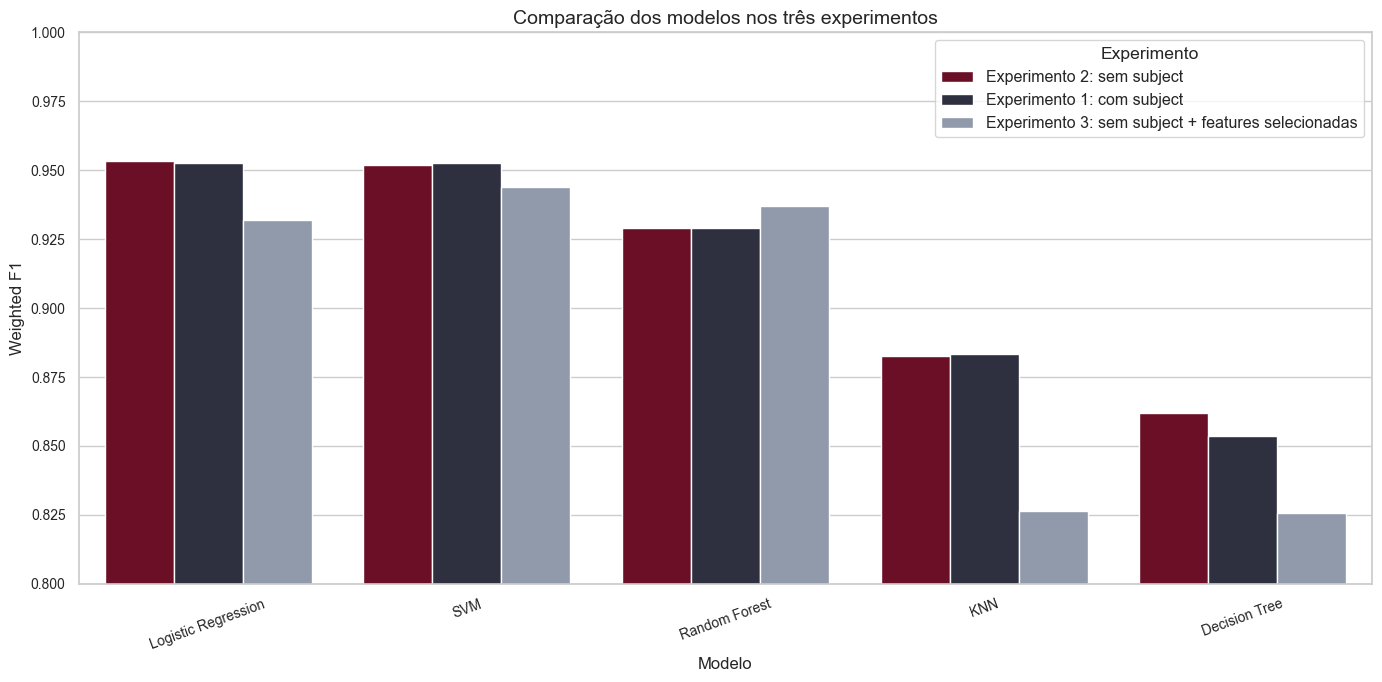

In [13]:
comparison_plot_df = comparison_table_extended.copy()
comparison_plot_palette = [dark_palette[1], dark_palette[4], dark_palette[6]]

plt.figure(figsize=(14, 7))
sns.barplot(
    data=comparison_plot_df,
    x="modelo",
    y="weighted_f1",
    hue="nome_experimento",
    palette=comparison_plot_palette,
)
plt.title("Comparação dos modelos nos três experimentos")
plt.xlabel("Modelo")
plt.ylabel("Weighted F1")
plt.xticks(rotation=20)
plt.ylim(0.80, 1.00)
plt.legend(title="Experimento")
plt.tight_layout()
plt.show()

## avaliação detalhada do melhor modelo da abordagem principal

a próxima etapa aprofunda a leitura do melhor modelo **dentro do cenário recomendado**, isto é, sem `subject`. isso mantém a análise consistente com a hipótese de generalização para participantes novos

In [14]:
best_experiment = recommended_best_row["experimento"]
best_model_name = recommended_best_row["modelo"]
best_artifacts = artifacts[(best_experiment, best_model_name)]
best_model = best_artifacts["model"]
y_pred_best = best_artifacts["predictions"]

report_df = pd.DataFrame(best_artifacts["classification_report"]).T
display(Markdown(f"melhor modelo da abordagem principal: {best_model_name} ({best_experiment})"))
display(report_df)

melhor modelo da abordagem principal: Logistic Regression (sem_subject)

,precision,recall,f1-score,support
LAYING,0.998127,0.992551,0.995331,537.000000
SITTING,0.966292,0.875764,0.918803,491.000000
STANDING,0.889845,0.971805,0.929021,532.000000
WALKING,0.940840,0.993952,0.966667,496.000000
WALKING_DOWNSTAIRS,0.989899,0.933333,0.960784,420.000000
WALKING_UPSTAIRS,0.952891,0.944798,0.948827,471.000000
accuracy,0.953512,0.953512,0.953512,0.953512
macro avg,0.956316,0.952034,0.953239,2947.000000
weighted avg,0.955231,0.953512,0.953430,2947.000000


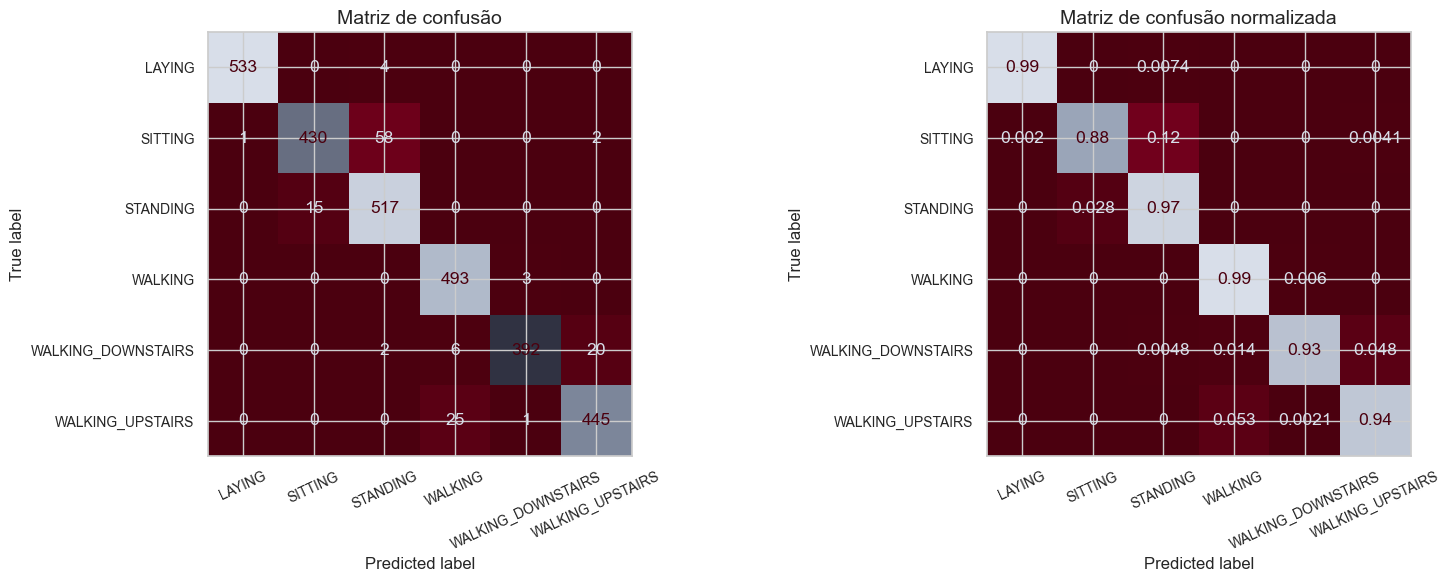

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred_best,
    display_labels=class_names,
    cmap=cmap,
    xticks_rotation=25,
    ax=axes[0],
    colorbar=False
)
axes[0].set_title("Matriz de confusão")

ConfusionMatrixDisplay.from_predictions(
    y_test_encoded,
    y_pred_best,
    display_labels=class_names,
    cmap=cmap,
    xticks_rotation=25,
    normalize="true",
    ax=axes[1],
    colorbar=False
)
axes[1].set_title("Matriz de confusão normalizada")

plt.tight_layout()
plt.show()

## análise dos erros

a matriz de confusão mostra **onde** o modelo erra; esta seção tenta explicar por que esses erros acontecem

em reconhecimento de atividades humanas, isso é esperado principalmente em dois grupos:

- `SITTING` x `STANDING`, porque ambas são atividades estáticas com pouca aceleração;
- `WALKING`, `WALKING_UPSTAIRS` e `WALKING_DOWNSTAIRS`, porque todas representam locomoção e compartilham padrões parecidos de movimento, mudando mais em intensidade e orientação do que em natureza

In [26]:
cm = best_artifacts["confusion_matrix"]
confusion_pairs = []

for i, actual in enumerate(class_names):
    for j, predicted in enumerate(class_names):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                "actual": actual,
                "predicted": predicted,
                "count": cm[i, j]
            })

confusion_df = pd.DataFrame(confusion_pairs).sort_values("count", ascending=False)
display(confusion_df.head(10))

targeted_confusions = pd.DataFrame([
    {
        "par": "SITTING -> STANDING",
        "erros": int(cm[np.where(class_names == "SITTING")[0][0], np.where(class_names == "STANDING")[0][0]])
    },
    {
        "par": "STANDING -> SITTING",
        "erros": int(cm[np.where(class_names == "STANDING")[0][0], np.where(class_names == "SITTING")[0][0]])
    },
    {
        "par": "WALKING -> WALKING_UPSTAIRS",
        "erros": int(cm[np.where(class_names == "WALKING")[0][0], np.where(class_names == "WALKING_UPSTAIRS")[0][0]])
    },
    {
        "par": "WALKING_UPSTAIRS -> WALKING",
        "erros": int(cm[np.where(class_names == "WALKING_UPSTAIRS")[0][0], np.where(class_names == "WALKING")[0][0]])
    },
    {
        "par": "WALKING_DOWNSTAIRS -> WALKING",
        "erros": int(cm[np.where(class_names == "WALKING_DOWNSTAIRS")[0][0], np.where(class_names == "WALKING")[0][0]])
    },
    {
        "par": "WALKING_DOWNSTAIRS -> WALKING_UPSTAIRS",
        "erros": int(cm[np.where(class_names == "WALKING_DOWNSTAIRS")[0][0], np.where(class_names == "WALKING_UPSTAIRS")[0][0]])
    }
])

display(targeted_confusions)

,actual,predicted,count
2,SITTING,STANDING,58
9,WALKING_UPSTAIRS,WALKING,25
8,WALKING_DOWNSTAIRS,WALKING_UPSTAIRS,20
4,STANDING,SITTING,15
7,WALKING_DOWNSTAIRS,WALKING,6
0,LAYING,STANDING,4
5,WALKING,WALKING_DOWNSTAIRS,3
3,SITTING,WALKING_UPSTAIRS,2
6,WALKING_DOWNSTAIRS,STANDING,2
1,SITTING,LAYING,1


,par,erros
0,SITTING -> STANDING,58
1,STANDING -> SITTING,15
2,WALKING -> WALKING_UPSTAIRS,0
3,WALKING_UPSTAIRS -> WALKING,25
4,WALKING_DOWNSTAIRS -> WALKING,6
5,WALKING_DOWNSTAIRS -> WALKING_UPSTAIRS,20


- a principal confusão do modelo ocorreu entre `SITTING` e `STANDING`, o que faz sentido porque ambas são atividades estáticas e apresentam baixa movimentação

- nesse caso, a diferença entre as classes depende mais de postura e orientação corporal do que de sinais intensos de aceleração, o que torna a separação mais difícil

- entre as atividades dinâmicas, também aparecem erros entre `WALKING`, `WALKING_UPSTAIRS` e `WALKING_DOWNSTAIRS`
  - isso era esperado, pois as três classes compartilham o mesmo padrão geral de locomoção
  - a diferença entre elas está mais no tipo de deslocamento e na distribuição de esforço do movimento

- no geral, a matriz de confusão indica que o modelo aprendeu bem a distinguir atividades estáticas de dinâmicas
  - as maiores dificuldades aparecem justamente nas fronteiras mais finas entre classes fisicamente parecidas

## avaliação detalhada do melhor modelo com features selecionadas

como a eda mostrou alta redundância entre variáveis, vale investigar se a base reduzida preserva os principais padrões de acerto e erro. nesta etapa, vamos olhar apenas para o melhor modelo dentro do experimento 3 e compará-lo com a versão completa sem `subject`

melhor modelo do experimento 3: **SVM** (`sem_subject_features_selecionadas`)

,precision,recall,f1-score,support
LAYING,0.990291,0.949721,0.969582,537.000000
SITTING,0.916840,0.898167,0.907407,491.000000
STANDING,0.884956,0.939850,0.911577,532.000000
WALKING,0.961014,0.993952,0.977205,496.000000
WALKING_DOWNSTAIRS,0.939815,0.966667,0.953052,420.000000
WALKING_UPSTAIRS,0.977324,0.915074,0.945175,471.000000
accuracy,0.943672,0.943672,0.943672,0.943672
macro avg,0.945040,0.943905,0.944000,2947.000000
weighted avg,0.944844,0.943672,0.943778,2947.000000


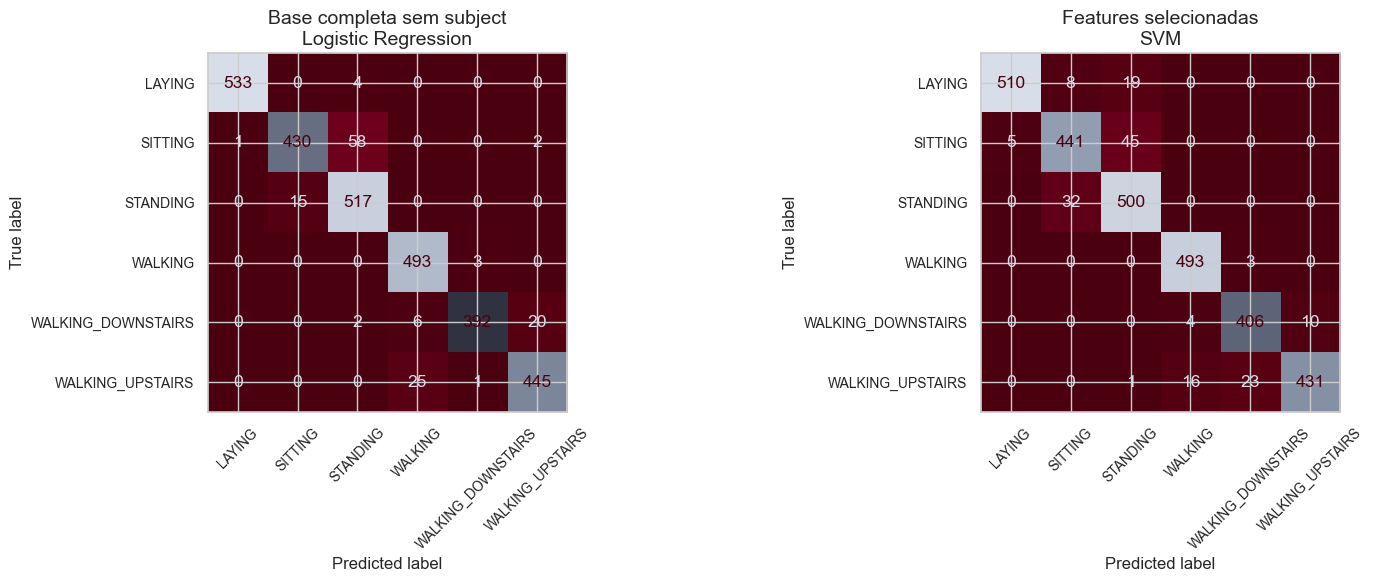

In [17]:
selected_results = (
    results_df[results_df["experimento"] == selected_experiment_key]
    .sort_values(by=["weighted_f1", "macro_f1", "accuracy"], ascending=False)
    .reset_index(drop=True)
)

best_selected_row = selected_results.iloc[0]
best_selected_model_name = best_selected_row["modelo"]
best_selected_artifacts = artifacts[(selected_experiment_key, best_selected_model_name)]
best_selected_model = best_selected_artifacts["model"]
selected_predictions = best_selected_artifacts["predictions"]

selected_report_df = pd.DataFrame(best_selected_artifacts["classification_report"]).T
display(Markdown(
    f"melhor modelo do experimento 3: **{best_selected_model_name}** (`{selected_experiment_key}`)"
))
display(selected_report_df)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ConfusionMatrixDisplay(
    confusion_matrix=best_artifacts["confusion_matrix"],
    display_labels=class_names,
).plot(ax=axes[0], cmap=cmap, colorbar=False, xticks_rotation=45)
axes[0].set_title(f"Base completa sem subject\n{best_model_name}")

ConfusionMatrixDisplay(
    confusion_matrix=best_selected_artifacts["confusion_matrix"],
    display_labels=class_names,
).plot(ax=axes[1], cmap=cmap, colorbar=False, xticks_rotation=45)
axes[1].set_title(f"Features selecionadas\n{best_selected_model_name}")

plt.tight_layout()
plt.show()

In [27]:
def summarize_targeted_confusions(confusion_matrix_values, class_names):
    def get_count(actual, predicted):
        actual_idx = np.where(class_names == actual)[0][0]
        predicted_idx = np.where(class_names == predicted)[0][0]
        return int(confusion_matrix_values[actual_idx, predicted_idx])

    return pd.DataFrame([
        {"par": "SITTING -> STANDING", "erros": get_count("SITTING", "STANDING")},
        {"par": "STANDING -> SITTING", "erros": get_count("STANDING", "SITTING")},
        {"par": "WALKING -> WALKING_UPSTAIRS", "erros": get_count("WALKING", "WALKING_UPSTAIRS")},
        {"par": "WALKING_UPSTAIRS -> WALKING", "erros": get_count("WALKING_UPSTAIRS", "WALKING")},
        {"par": "WALKING_DOWNSTAIRS -> WALKING", "erros": get_count("WALKING_DOWNSTAIRS", "WALKING")},
        {"par": "WALKING_DOWNSTAIRS -> WALKING_UPSTAIRS", "erros": get_count("WALKING_DOWNSTAIRS", "WALKING_UPSTAIRS")},
    ])

base_confusion_focus_df = summarize_targeted_confusions(
    best_artifacts["confusion_matrix"], class_names
).rename(columns={"erros": "erros_base_completa"})

selected_confusion_focus_df = summarize_targeted_confusions(
    best_selected_artifacts["confusion_matrix"], class_names
).rename(columns={"erros": "erros_features_selecionadas"})

selected_confusion_comparison_df = base_confusion_focus_df.merge(
    selected_confusion_focus_df,
    on="par"
)

selected_confusion_comparison_df["diferença"] = (
    selected_confusion_comparison_df["erros_features_selecionadas"]
    - selected_confusion_comparison_df["erros_base_completa"]
)

display(selected_confusion_comparison_df)

selected_vs_full_metrics_df = pd.DataFrame([
    {
        "cenário": "Base completa sem subject",
        "modelo": best_model_name,
        "accuracy": recommended_best_row["accuracy"],
        "macro_f1": recommended_best_row["macro_f1"],
        "weighted_f1": recommended_best_row["weighted_f1"],
        "quantidade_features": experiments[best_experiment]["X_train"].shape[1],
    },
    {
        "cenário": "Features selecionadas",
        "modelo": best_selected_model_name,
        "accuracy": best_selected_row["accuracy"],
        "macro_f1": best_selected_row["macro_f1"],
        "weighted_f1": best_selected_row["weighted_f1"],
        "quantidade_features": experiments[selected_experiment_key]["X_train"].shape[1],
    },
])

display(selected_vs_full_metrics_df.round({
    "accuracy": 4,
    "macro_f1": 4,
    "weighted_f1": 4,
}))

,par,erros_base_completa,erros_features_selecionadas,diferença
0,SITTING -> STANDING,58,45,-13
1,STANDING -> SITTING,15,32,17
2,WALKING -> WALKING_UPSTAIRS,0,0,0
3,WALKING_UPSTAIRS -> WALKING,25,16,-9
4,WALKING_DOWNSTAIRS -> WALKING,6,4,-2
5,WALKING_DOWNSTAIRS -> WALKING_UPSTAIRS,20,10,-10


,cenário,modelo,accuracy,macro_f1,weighted_f1,quantidade_features
0,Base completa sem subject,Logistic Regression,0.9535,0.9532,0.9534,561
1,Features selecionadas,SVM,0.9437,0.9440,0.9438,140


- no experimento com features selecionadas, o melhor modelo foi o SVM, com desempenho inferior ao melhor cenário da base completa sem `subject`, mas ainda competitivo considerando a redução expressiva no número de variáveis

- a comparação mostra que a base reduzida preservou boa parte da capacidade preditiva do problema, embora com alguma perda em relação à base completa

- em termos de erro, a matriz de confusão continua concentrando as principais dificuldades entre atividades fisicamente parecidas, especialmente `SITTING` e `STANDING`, além das variações de caminhada

- isso sugere que a seleção de features não alterou a natureza do problema: a base ficou mais enxuta, mas as fronteiras mais difíceis continuaram sendo as mesmas

- na prática, esse resultado indica que a redução de variáveis pode ser útil como alternativa de simplificação e interpretação, embora a base completa ainda apresente o melhor desempenho global

## validação cruzada tradicional

antes de introduzir a validação por participante, vamos medir a consistência do melhor modelo com uma validação cruzada tradicional. aqui, os folds misturam observações de participantes diferentes, o que costuma gerar uma estimativa mais otimista

In [28]:
X_best_train = experiments[best_experiment]["X_train"]
stratified_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    best_model,
    X_best_train,
    y_train_encoded,
    cv=stratified_cv,
    scoring="f1_weighted"
)

cv_df = pd.DataFrame({
    "fold": [f"Fold {i}" for i in range(1, len(cv_scores) + 1)],
    "weighted_f1": cv_scores
})

display(cv_df.round({"weighted_f1": 4}))

,fold,weighted_f1
0,Fold 1,0.9816
1,Fold 2,0.9898
2,Fold 3,0.9830
3,Fold 4,0.9864
4,Fold 5,0.9823


a validação cruzada tradicional reforça a consistência do modelo. a média do `weighted_f1` resume o desempenho médio nos 5 folds, enquanto o desvio padrão mostra o quanto esse resultado varia entre as divisões. valores próximos entre os folds indicam um modelo mais estável e com menor sensibilidade à forma como o conjunto de treino é particionado

## validação por participante

agora usamos `GroupKFold` com a coluna `subject` como grupo. esse desenho é mais realista porque força o modelo a ser avaliado em participantes que não apareceram no treino

o modelo reconhece a atividade de uma pessoa nova ou apenas reproduz padrões de pessoas já vistas?

In [29]:
group_cv = GroupKFold(n_splits=5)
group_scores = cross_val_score(
    best_model,
    X_best_train,
    y_train_encoded,
    cv=group_cv,
    scoring="f1_weighted",
    groups=subject_groups
)

group_cv_df = pd.DataFrame({
    "fold": [f"Grupo {i}" for i in range(1, len(group_scores) + 1)],
    "weighted_f1": group_scores
})

cv_comparison_df = pd.DataFrame({
    "estratégia": ["validação tradicional", "validação por participante"],
    "weighted_f1_médio": [cv_scores.mean(), group_scores.mean()],
    "desvio_padrão": [cv_scores.std(), group_scores.std()]
})

display(group_cv_df.round({"weighted_f1": 4}))
display(cv_comparison_df.round({
    "weighted_f1_médio": 4,
    "desvio_padrão": 4
}))

gap = cv_scores.mean() - group_scores.mean()
print(f"gap entre as estratégias: {gap:.4f}")

,fold,weighted_f1
0,Grupo 1,0.8807
1,Grupo 2,0.8988
2,Grupo 3,0.9795
3,Grupo 4,0.9710
4,Grupo 5,0.9430


,estratégia,weighted_f1_médio,desvio_padrão
0,validação tradicional,0.9846,0.0031
1,validação por participante,0.9346,0.0390


gap entre as estratégias: 0.0500


houve queda de `0.0500` no `weighted_f1` médio em relação à validação tradicional, indicando que generalizar para pessoas novas é mais difícil do que prever registros de participantes já vistos no treino. mesmo assim, o resultado ainda permaneceu alto, o que reforça a robustez do modelo

## ajuste de hiperparâmetros

com o melhor modelo da abordagem principal definido, vale fazer um ajuste leve de hiperparâmetros. a ideia aqui não é exaurir todas as combinações, mas testar se existe um ganho simples sem deixar o notebook pesado demais

In [30]:
if best_model_name == "Logistic Regression":
    tuning_grid = {
        "model__C": [0.1, 1.0, 5.0, 10.0],
        "model__solver": ["lbfgs"]
    }
elif best_model_name == "SVM":
    tuning_grid = {
        "model__C": [0.5, 1.0, 3.0],
        "model__gamma": ["scale", "auto"]
    }
elif best_model_name == "Random Forest":
    tuning_grid = {
        "n_estimators": [150, 250],
        "max_depth": [None, 15, 25],
        "min_samples_split": [2, 5]
    }
else:
    tuning_grid = {
        "max_depth": [None, 10, 20],
        "min_samples_split": [2, 5, 10]
    }

tuning_search = GridSearchCV(
    estimator=clone(best_model),
    param_grid=tuning_grid,
    scoring="f1_weighted",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=None,
    refit=True
)

tuning_search.fit(X_best_train, y_train_encoded)
tuned_model = tuning_search.best_estimator_
tuned_predictions = tuned_model.predict(experiments[best_experiment]["X_test"])

tuning_comparison_df = pd.DataFrame([
    {
        "versão": "baseline",
        "accuracy": accuracy_score(y_test_encoded, y_pred_best),
        "macro_f1": f1_score(y_test_encoded, y_pred_best, average="macro"),
        "weighted_f1": f1_score(y_test_encoded, y_pred_best, average="weighted")
    },
    {
        "versão": "ajustada",
        "accuracy": accuracy_score(y_test_encoded, tuned_predictions),
        "macro_f1": f1_score(y_test_encoded, tuned_predictions, average="macro"),
        "weighted_f1": f1_score(y_test_encoded, tuned_predictions, average="weighted")
    }
])

display(pd.DataFrame({
    "melhores_parâmetros": [tuning_search.best_params_],
    "melhor_score_cv": [tuning_search.best_score_]
}))

display(tuning_comparison_df.round({
    "accuracy": 4,
    "macro_f1": 4,
    "weighted_f1": 4
}))

final_model = tuned_model
final_predictions_encoded = tuned_predictions
final_model_origin = "modelo ajustado"
final_predictions_labels = label_encoder.inverse_transform(final_predictions_encoded)

,melhores_parâmetros,melhor_score_cv
0,"{'model__C': 1.0, 'model__solver': 'lbfgs'}",0.984623


,versão,accuracy,macro_f1,weighted_f1
0,baseline,0.9535,0.9532,0.9534
1,ajustada,0.9535,0.9532,0.9534


o ajuste de hiperparâmetros não melhorou o desempenho do modelo. a regressão logística baseline já apresentava a mesma performance da versão ajustada, o que sugere que a configuração inicial já era adequada para o problema

## importância das variáveis e interpretação

além de comparar métricas, vale observar quais features parecem contribuir mais para a separação entre as atividades

se o modelo final oferecer uma medida nativa de importância, usamos essa informação diretamente. caso contrário, recorremos a um **Random Forest auxiliar** como apoio interpretativo, já que ele produz importâncias de forma mais direta


Critério usado: **Random Forest auxiliar para interpretação**

,feature,importance
40,tGravityAcc-mean()-X,0.038470
52,tGravityAcc-min()-X,0.030480
41,tGravityAcc-mean()-Y,0.029454
558,"angle(X,gravityMean)",0.027976
56,tGravityAcc-energy()-X,0.025576
559,"angle(Y,gravityMean)",0.022505
53,tGravityAcc-min()-Y,0.022289
50,tGravityAcc-max()-Y,0.021422
49,tGravityAcc-max()-X,0.021201
57,tGravityAcc-energy()-Y,0.016772


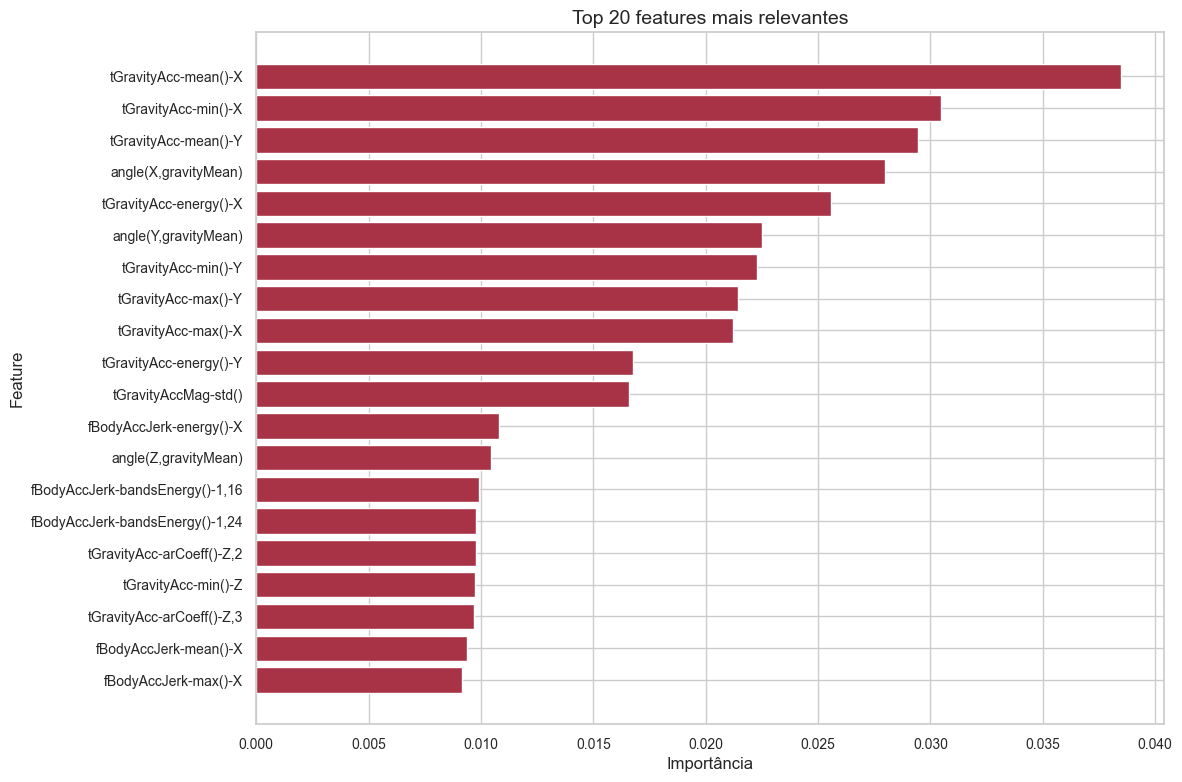

In [22]:
final_feature_names = experiments[best_experiment]["X_train"].columns

if hasattr(final_model, "feature_importances_"):
    importance_values = final_model.feature_importances_
    importance_kind = "importância nativa do modelo final"
elif hasattr(final_model, "named_steps") and "model" in final_model.named_steps and hasattr(final_model.named_steps["model"], "coef_"):
    auxiliary_model = RandomForestClassifier(random_state=42, n_estimators=200)
    auxiliary_model.fit(experiments[best_experiment]["X_train"], y_train_encoded)
    importance_values = auxiliary_model.feature_importances_
    importance_kind = "Random Forest auxiliar para interpretação"
else:
    auxiliary_model = RandomForestClassifier(random_state=42, n_estimators=200)
    auxiliary_model.fit(experiments[best_experiment]["X_train"], y_train_encoded)
    importance_values = auxiliary_model.feature_importances_
    importance_kind = "Random Forest auxiliar para interpretação"

importance_df = pd.DataFrame({
    "feature": final_feature_names,
    "importance": importance_values
}).sort_values("importance", ascending=False)

top_importance = importance_df.head(20).sort_values("importance")
display(Markdown(f"Critério usado: **{importance_kind}**"))
display(importance_df.head(20))

plt.figure(figsize=(12, 8))
plt.barh(top_importance["feature"], top_importance["importance"], color=dark_palette[2])
plt.title("Top 20 features mais relevantes")
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

em termos práticos, muitas das features mais importantes estão ligadas a:

- **gravidade e orientação corporal**, o que ajuda a distinguir posturas como `LAYING`, `SITTING` e `STANDING`;
- **energia, frequência e magnitude do movimento**, que ajudam a separar atividades dinâmicas das estáticas;
- **componentes do giroscópio e da aceleração**, úteis para captar mudanças finas entre diferentes formas de caminhar.

## predições finais e arquivo de saída

diferente de alguns desafios do Kaggle, este `test.csv` já traz a variável real `Activity`. por isso, além de gerar as previsões do modelo final, também conseguimos comparar diretamente os acertos e salvar um arquivo final para consulta

In [23]:
predictions_df = pd.DataFrame({
    "subject": test_df["subject"] if "subject" in test_df.columns else np.arange(len(test_df)),
    "actual_activity": y_test_full,
    "predicted_activity": final_predictions_labels,
    "correct_prediction": y_test_full == final_predictions_labels
})

predictions_df.to_csv("../data/human_activity_predictions.csv", index=False)
display(predictions_df.head())
print(f"Arquivo salvo em ../data/human_activity_predictions.csv com {len(predictions_df)} linhas.")
print(f"Taxa de acerto no conjunto de teste: {predictions_df['correct_prediction'].mean():.4f}")

,subject,actual_activity,predicted_activity,correct_prediction
0,2,STANDING,STANDING,True
1,2,STANDING,STANDING,True
2,2,STANDING,STANDING,True
3,2,STANDING,STANDING,True
4,2,STANDING,STANDING,True


Arquivo salvo em ../data/human_activity_predictions.csv com 2947 linhas.
Taxa de acerto no conjunto de teste: 0.9535


## conclusão do experimento com as features selecionadas

In [31]:
per_model_delta_df = (
    comparison_table_extended
    .pivot_table(index="modelo", columns="nome_experimento", values="weighted_f1")
    .reset_index()
)

full_label = "Experimento 2: sem subject"
selected_label = "Experimento 3: sem subject + features selecionadas"

per_model_delta_df["delta_selected_vs_full"] = (
    per_model_delta_df[selected_label] - per_model_delta_df[full_label]
)

display(per_model_delta_df.round(4))

nome_experimento,modelo,Experimento 1: com subject,Experimento 2: sem subject,Experimento 3: sem subject + features selecionadas,delta_selected_vs_full
0,Decision Tree,0.8536,0.8620,0.8256,-0.0364
1,KNN,0.8834,0.8827,0.8264,-0.0563
2,Logistic Regression,0.9525,0.9534,0.9318,-0.0216
3,Random Forest,0.9290,0.9289,0.9369,0.0080
4,SVM,0.9524,0.9517,0.9438,-0.0079


a versão reduzida da base permitiu testar se uma quantidade menor de variáveis, com menos redundância, conseguiria preservar o desempenho da modelagem. no resultado geral, a base com features selecionadas ficou abaixo da base completa sem `subject`, indicando que parte da informação removida ainda contribuía para a classificação final

mesmo assim, a perda não foi uniforme entre os modelos. alguns algoritmos foram mais sensíveis à redução de variáveis, enquanto outros mantiveram desempenho mais próximo da versão completa. isso sugere que a seleção de features pode ser mais vantajosa para certos tipos de modelo do que para outros

em termos qualitativos, os principais erros continuaram concentrados entre atividades fisicamente parecidas, como `SITTING` e `STANDING` ou entre as variações de caminhada. isso mostra que a redução de features não mudou a natureza do problema, apenas reduziu parte da capacidade discriminativa do conjunto original

por isso, esse experimento continua sendo valioso no projeto, pois ele ajuda a comparar desempenho, simplicidade e interpretabilidade, além de abrir espaço para futuros testes com outros critérios de seleção de variáveis

## conclusão


- **objetivo do projeto:** prever a atividade humana (`Activity`) a partir de variáveis derivadas de sensores de smartphone, em um problema de classificação multiclasse
- **modelos testados:** Logistic Regression, Decision Tree, Random Forest, KNN e SVM, comparando três cenários: com `subject`, sem `subject` e sem `subject` com features selecionadas
- **melhor abordagem recomendada:** Logistic Regression no experimento **sem `subject`**, que também apresentou o melhor resultado geral. essa foi mantida como referência principal por reduzir o risco de capturar atalhos ligados ao participante, em vez do padrão da atividade
- **métricas principais do modelo final:** `accuracy = 0.9535`, `macro_f1 = 0.9532` e `weighted_f1 = 0.9534`, com o `weighted_f1` como métrica principal de comparação entre os modelos
- **principais erros observados:** a maior dificuldade apareceu entre `SITTING` e `STANDING`, além de algumas trocas entre `WALKING`, `WALKING_UPSTAIRS` e `WALKING_DOWNSTAIRS`, o que faz sentido pela semelhança física entre essas atividades
- **leitura metodológica importante:** a validação por participante foi mais exigente do que a validação tradicional, mostrando que parte do desempenho cai quando o modelo precisa generalizar para pessoas não vistas anteriormente
- **limitações do estudo:** o dataset já traz features prontas, então este projeto não explora o processamento do sinal bruto. além disso, a validação tradicional tende a ser mais otimista do que cenários em que o modelo precisa prever atividades de indivíduos totalmente novos